In [ ]:
from keras.datasets import fashion_mnist
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [ ]:
(X_train_raw,y_train_raw),(X_test_raw,y_test_raw)= fashion_mnist.load_data()
X_val_raw=X_test_raw[-10000:]
y_val_raw=y_test_raw[-10000:]

X_train_raw=X_train_raw[:-10000]
y_train_raw=y_train_raw[:-10000]



# Images are 28x28 grids of pixels with values ranging from 0 to 255
# so I will flatten the 2D to 1D vectors (784 features)and scale the pixels to be between 0 and 1
# FLATTENING
X_train = X_train_raw.reshape(-1,784)/ 255.0
X_val=X_val_raw.reshape(-1,784)/255.0
X_test=X_test_raw.reshape(-1,784)/255.0


# One hot encode the labels 
def one_hot(y,num_classes=10):
    # np.eye creates an identity matrix, and indexing it with 'y'
    return np.eye(num_classes)[y]

y_train=one_hot(y_train_raw)
y_val=one_hot(y_val_raw)
y_test=one_hot(y_test_raw)


##### BUILDING A VANILLA MLP

In [ ]:
#Parameter initialization 
def init_params(initialization):
    W1=np.random.randn(784,100) *initialization
    b1=np.zeros((1,100))

    W2=np.random.randn(100,100) * initialization
    b2=np.zeros((1,100))
    
    W3= np.random.randn(100,10) *initialization
    b3 = np.zeros((1,10))

    return {'W1':W1, 'b1':b1,"W2":W2,"b2":b2,"W3":W3,"b3":b3}

def Tanh(Z):
    return np.tanh(Z)

def softmax(Z):
    exp_Z=np.exp(Z - np.max(Z, axis =1 , keepdims=True))
    return exp_Z/ np.sum(exp_Z, axis =1 , keepdims = True)

def foward_pass(X, params):
    # Layer 1 
    Z1=np.dot(X, params["W1"]) + params["b1"]
    A1= Tanh(Z1)

    # Layer 2
    Z2 =np.dot(A1,params["W2"]) + params["b2"]
    A2= Tanh(Z2)

    # Layer 3 
    Z3=np.dot(A2,params["W3"])+ params["b3"]
    A3 = softmax(Z3)

    cache={"Z1":Z1 , "A1":A1, "Z2":Z2, "A2":A2, "Z3": Z3 , "A3":A3}

    return A3, cache

def loss_function(Y_true,Y_pred):

    m= Y_true.shape[0] # number of examples in the batch 

    epsilon=1e-15
    y_pred_clipped= np.clip(Y_pred, epsilon, 1 - epsilon)
    loss = -np.sum(Y_true* np.log(y_pred_clipped))/m

    return loss

def backward_pass(X, Y, cache, params):
    m=X.shape[0] # Batch size

    # activation from the foward pass
    A1= cache["A1"]
    A2= cache["A2"]
    A3= cache["A3"]

    W2= params["W2"]
    W3 = params["W3"]

    # layer 3 the output
    dZ3= A3- Y
    dW3 = (1/m) * np.dot(A2.T, dZ3)
    db3=(1/m) * np.sum(dZ3, axis=0, keepdims=True)
    
    # the derivative of Tanh
    dA2= np.dot(dZ3 , W3.T)
    dZ2= dA2 * (1- np.power(A2, 2))
    dW2 =  (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    # Layer 1
    dA1= np.dot(dZ2, W2.T)
    dZ1= dA1 * (1-np.power(A1, 2))
    dW1= (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0,keepdims=True)

    # Store the gradients in a dictionary 
    grads= {"dW1":dW1, "db1":db1, "dW2":dW2, "db2":db2, "dW3":dW3,"db3":db3} 

    return grads

def update_params(params, grads, learning_rate):
    '''this is the optimizer calculated as W=W-(Lr*dW) dW being the derivative of W, while 
        W is the parameter in question'''
    params["W1"] -= learning_rate * grads["dW1"]
    params["b1"] -= learning_rate * grads["db1"]
    params["W2"] -= learning_rate * grads["dW2"]
    params["b2"] -= learning_rate * grads["db2"]
    params["W3"] -= learning_rate * grads["dW3"]
    params["b3"] -= learning_rate * grads["db3"]

    return params 
    

In [ ]:
steps=20000
batch_size=32

def training_vanilla(lr,batch_size=32,steps=20000,initialization=0.1):
    history={
        "steps":[],
        "train_loss":[],
        "val_loss":[],
        "val_acc":[]
    }
    params= init_params(initialization)
    m = X_train.shape[0]

    for step in range(steps):
        # shuffling the data first 
        ix=np.random.randint(0,m, size=batch_size)
        X_batch=X_train[ix]
        y_batch=y_train[ix]

        # foward_pass
        A3,cache= foward_pass(X=X_batch,params= params)
        loss= loss_function(Y_true=y_batch, Y_pred=A3)
        grads=backward_pass(X=X_batch,Y= y_batch,cache=cache, params=params)
        params = update_params(params= params, grads=grads, learning_rate=lr)
        if step % 100 == 0:
            A3_val,_=foward_pass(X_val,params)
            val_loss= loss_function(y_val, A3_val)
            
            val_preds=np.argmax(A3_val,axis=1)
            val_true=np.argmax(y_val,axis=1)
            val_acc=np.mean(val_preds == val_true) *100

            # print(f"Step {step:5d} | Train Loss: {loss:.4f} | Val loss {val_loss:.4f}")
            history["steps"].append(step)
            history["val_loss"].append(val_loss)
            history["train_loss"].append(loss)
            history["val_acc"].append(val_acc)

    A3_test,_= foward_pass(X_test, params)
    test_loss = loss_function(y_test,A3_test)

    predictions= np.argmax(A3_test, axis=1)
    true_labels=np.argmax(y_test, axis=1)

    vanilla_accuracy=np.mean(predictions== true_labels) * 100
    
    return params,history,vanilla_accuracy


In [ ]:
_,normal_vanilla_history,normal_vanilla_accuracy=training_vanilla(lr=0.1)
# testing the initialization
_,big_initialization_vanilla_change_history,big_initialization_vanilla_accuracy=training_vanilla(lr=0.1,initialization=2)
_,small_initialization_vanilla_change_history,small_initialization_vanilla_accuracy=training_vanilla(lr=0.1,initialization=0.01)
# testing the breaking of using an different lr
_,big_lr_vanilla_history,big_lr_vanilla_accuracy=training_vanilla(lr=5)
_,small_lr_vanilla_history,small_lr_vanilla_accuracy=training_vanilla(lr=0.001)
# Tiny batch problem 
_,big_batchsize_vanilla_history,big_batchsize_vanilla_accuracy=training_vanilla(lr=0.1,batch_size=100)
_,small_batchsize_vanilla_history,small_batchsize_vanilla_accuracy=training_vanilla(lr=0.1,batch_size=10)


### BATCH NORMALIZATION

In [ ]:
class Linear:
    def __init__(self, fan_in,fan_out,bias=True):

        # using Kaiming initialization instead of what I initially used ( 0.1)
        self.weight=np.random.randn(fan_in,fan_out)/ np.sqrt(fan_in)
        self.bias=np.zeros((1,fan_out)) if bias else None

        # Gradient are stored here
        self.dW= None
        self.db = None

    def foward(self, x):
        self.x = x
        out= np.dot(x, self.weight)
        if self.bias is not None:
            out +=self.bias 
        return out 
    def backward(self, d_out):
        m= self.x.shape[0]  #batch size

        #calculate the gradients
        self.dW= np.dot(self.x.T, d_out)/ m
        if self.bias is not None:
            self.db = np.sum(d_out,axis=0, keepdims=True)/m
        
        # Calculate the derivative to pass backward to the previous layer

        d_x= np.dot(d_out, self.weight.T)
        return d_x
    def update(self,lr):
        self.weight -= lr* self.dW
        if self.bias is not None:
            self.bias -= lr* self.db

class Tanh:
    def __init__(self):
        self.out = None

    def foward(self,x):
        self.out=np.tanh(x)
        return self.out
    def backward(self,d_out):
        d_x=d_out * (1-np.power(self.out,2))
        return d_x
    
    def update(self,lr):
        pass


class BatchNorm1d:
    def __init__(self,dim,eps=1e-5, momentum=0.1):
        self.eps=eps
        self.momentum = momentum
        self.training=True

        # Parameters
        self.gamma = np.ones((1,dim))
        self.beta= np.zeros((1,dim))

        # Gradients 
        self.dgamma=None
        self.dbeta=None

        # Buffers
        self.running_mean=np.zeros((1,dim))
        self.running_var=np.ones((1,dim))

        self.cache = None
    def foward(self,x):
        if self.training:
            mu=np.mean(x,axis=0, keepdims=True)
            var=np.var(x,axis=0,keepdims=True)

            # Normalize
            X_norm = (x-mu)/np.sqrt(var+self.eps)
            out = self.gamma * X_norm + self.beta

            # update buffers
            self.running_mean=(1-self.momentum) * self.running_mean +self.momentum *mu
            self.running_var = (1-self.momentum) * self.running_var + self.momentum * var

            self.cache = (x, X_norm,mu,var)
        else:
            X_norm=(x-self.running_mean)/ np.sqrt(self.running_var+self.eps)
            out= self.gamma * X_norm + self.beta
        return out
    def backward(self,d_out):
        X, X_norm,mu,var=self.cache
        m = X.shape[0]

        # gradients of the learnable parameters
        self.dgamma=np.sum(d_out*X_norm, axis=0,keepdims=True) 
        self.dbeta=np.sum(d_out,axis=0,keepdims=True)

        # simplified gradient for the input (dx)
        std_inv=1.0/np.sqrt(var + self.eps)

        dx= (self.gamma * std_inv/m) * (m*d_out- self.dbeta-X_norm * self.dgamma)
        
        return dx
    

    def update(self, lr):
        self.gamma -= lr * self.dgamma
        self.beta -= lr * self.dbeta


In [ ]:
# batch_size=32
# steps =20000
def training_bn(lr,batch_size=32,steps=20000):
    n_inputs = 784
    n_hidden = 100
    n_outputs = 10

    layers = [
        Linear(n_inputs,n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(),
        Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
        Linear(n_hidden,n_outputs,bias=True)
    ]

    steps =20000
    m=X_train.shape[0]
    history={
        "steps":[],
        "train_loss":[],
        "val_loss":[],
        "val_acc":[]
    }
    for step in range(steps):

        ix=np.random.randint(0,m,size=batch_size)
        X_batch= X_train[ix]
        y_batch= y_train[ix]

        # lr = 0.1 if step < 10000 else 0.01
        # lr=1.0

        # foward pass
        out=X_batch
        for layer in layers:
            out=layer.foward(out)
        
        exp_scores=np.exp(out-np.max(out,axis=1,keepdims=True))
        probs =  exp_scores/np.sum(exp_scores,axis=1,keepdims=True)

        # Calculating the loss
        loss = -np.sum(y_batch * np.log(probs+1e-15))/batch_size

        # Backward pass 
        # Derivative of softmax + cross entropy 
        d_out = probs - y_batch
        for layer in reversed(layers):
            d_out= layer.backward(d_out)

        # parameter updates 
        for layer in layers:
            layer.update(lr)

        if step % 100 == 0:
            for layer in layers:
                if isinstance(layer,BatchNorm1d):
                    layer.training=False
            out_val=X_val
            for layer in layers:
                out_val=layer.foward(out_val)
            
            # Softmax for getting probabilities 
            exp_scores_val= np.exp(out_val-np.max(out_val,axis=1,keepdims=True))
            probs_val=exp_scores_val / np.sum(exp_scores_val,axis=1,keepdims=True)

            val_loss=loss_function(y_val,probs_val)
            val_preds=np.argmax(probs_val,axis=1)
            val_true=np.argmax(y_val,axis=1)
            val_acc=np.mean(val_preds==val_true) *100

            history["val_acc"].append(val_acc)
            history["steps"].append(step)
            history["train_loss"].append(loss)
            history["val_loss"].append(val_loss)

            for layer in layers:
                if isinstance(layer, BatchNorm1d):
                    layer.training=True
            


    for layer in layers:
        if isinstance(layer, BatchNorm1d):
            layer.training= False
            
    out_test= X_test
    for layer in layers:
        out_test= layer.foward(out_test)

    # calculating the accuracy
    predictions = np.argmax(out_test, axis=1)
    true_labels= np.argmax(y_test,axis=1)
    accuracy = np.mean(predictions == true_labels) * 100

    return history, accuracy

In [ ]:
normal_bn_history,normal_bn_accuracy=training_bn(lr=0.1)

# testing the breaking of using an different lr
big_lr_bn_history,big_lr_bn_accuracy=training_bn(lr=5)
small_lr_bn_history,small_lr_bn_accuracy=training_bn(lr=0.001)

# Tiny batch problem 
big_batchsize_bn_history,big_batchsize_bn_accuracy=training_bn(lr=0.1,batch_size=100)
small_batchsize_bn_history,small_batchsize_bn_accuracy=training_bn(lr=0.1,batch_size=10)


### COMPARISON BETWEEN VANILLA AND BATCH NORMALIZATION

In [ ]:
def plot_experiments(steps_vanilla,val_loss_or_acc_van,steps_bn,val_loss_acc_bn,title,ylabel,log=True):
    """
    Plots validation loss and validation accuracy for multiple training runs
    they have different parameters but will be listed in the tittle"""

    plt.figure(figsize=(10,6))
    plt.plot(steps_vanilla,val_loss_or_acc_van,label="Vanilla Network",color="red", linestyle="--")

    plt.plot(steps_bn,val_loss_acc_bn,label="Batch Normalization Network", color="blue", linewidth=2)
    if log == True:
        plt.yscale('log') 
    else:
        pass
    plt.title(title, fontsize=16)
    plt.xlabel(f"Training Steps", fontsize=12)
    plt.ylabel(f"{ylabel}", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True,alpha=0.3)

    plt.show()

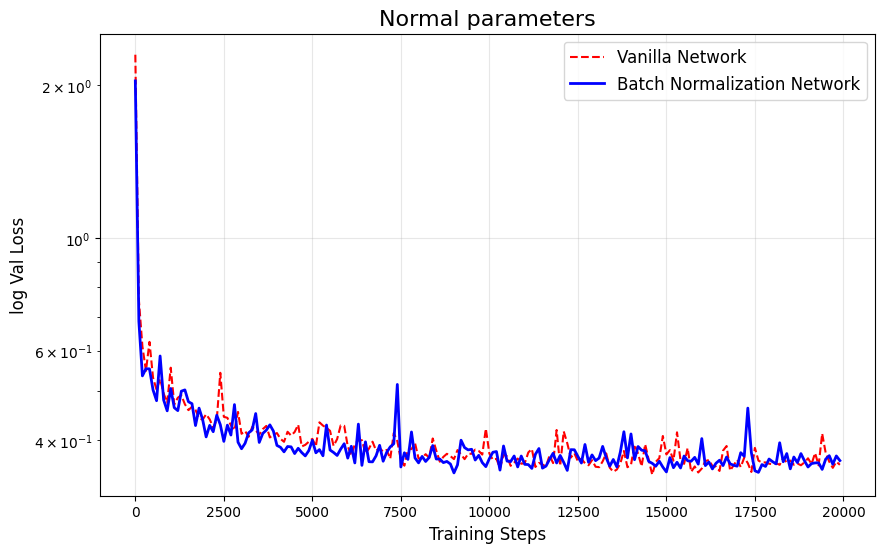

In [ ]:
plot_experiments(steps_vanilla=normal_vanilla_history["steps"]
                 ,val_loss_or_acc_van=normal_vanilla_history["val_loss"],
                 steps_bn=normal_bn_history["steps"],
                 val_loss_acc_bn=normal_bn_history["val_loss"],
                 title="Normal parameters",
                 ylabel="log Val Loss")

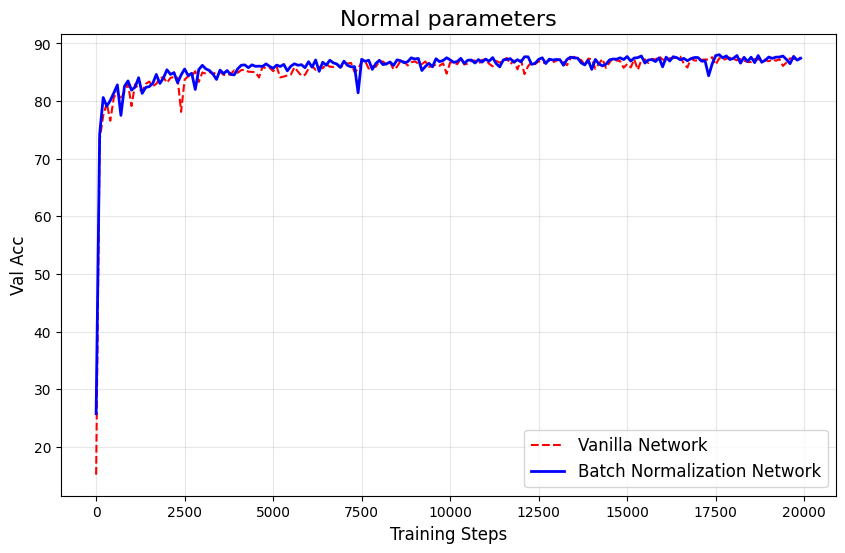

In [ ]:
plot_experiments(steps_vanilla=normal_vanilla_history["steps"]
                 ,val_loss_or_acc_van=normal_vanilla_history["val_acc"],
                 steps_bn=normal_bn_history["steps"],
                 val_loss_acc_bn=normal_bn_history["val_acc"],
                 title="Normal parameters",
                 ylabel="Val Acc"
                 ,log=False)

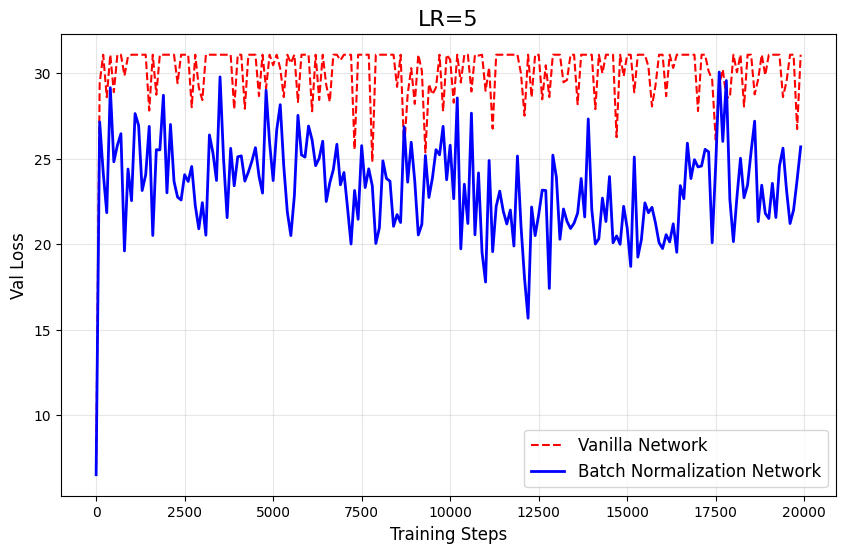

In [ ]:
plot_experiments(steps_vanilla=big_lr_vanilla_history["steps"]
                 ,val_loss_or_acc_van=big_lr_vanilla_history["val_loss"],
                 steps_bn=big_lr_bn_history["steps"],
                 val_loss_acc_bn=big_lr_bn_history["val_loss"],
                 title="LR=5",
                 ylabel="Val Loss",log=False)

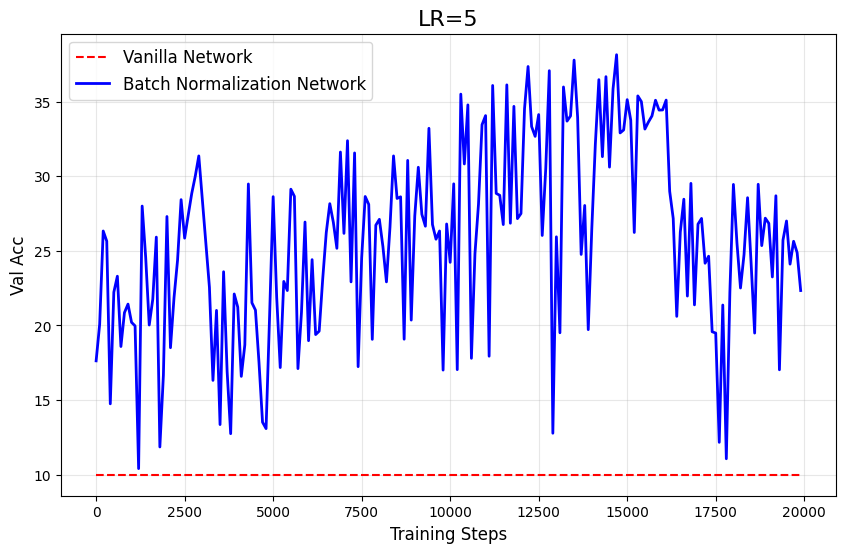

In [ ]:
plot_experiments(steps_vanilla=big_lr_vanilla_history["steps"]
                 ,val_loss_or_acc_van=big_lr_vanilla_history["val_acc"],
                 steps_bn=big_lr_bn_history["steps"],
                 val_loss_acc_bn=big_lr_bn_history["val_acc"],
                 title="LR=5",
                 ylabel="Val Acc"
                 ,log=False)

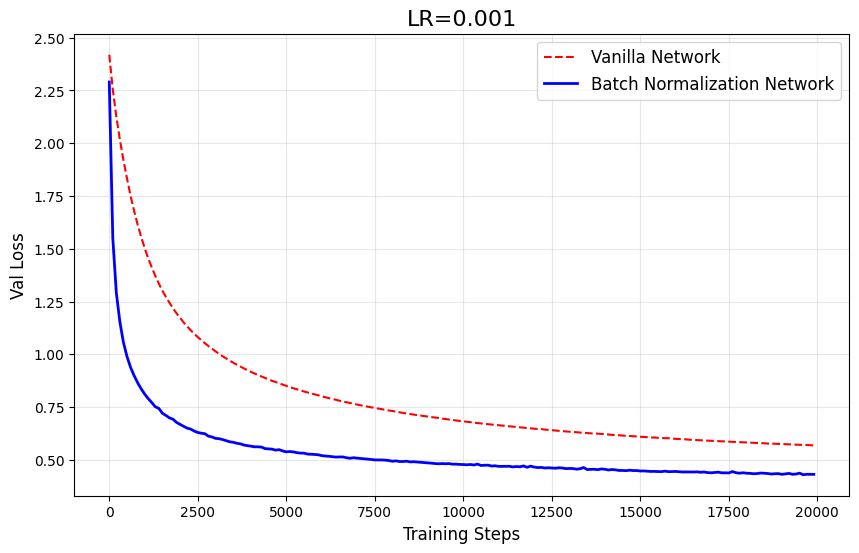

In [ ]:
# small_lr_bn_history
plot_experiments(steps_vanilla=small_lr_vanilla_history["steps"]
                 ,val_loss_or_acc_van=small_lr_vanilla_history["val_loss"],
                 steps_bn=small_lr_bn_history["steps"],
                 val_loss_acc_bn=small_lr_bn_history["val_loss"],
                 title="LR=0.001",
                 ylabel="Val Loss",log=False)

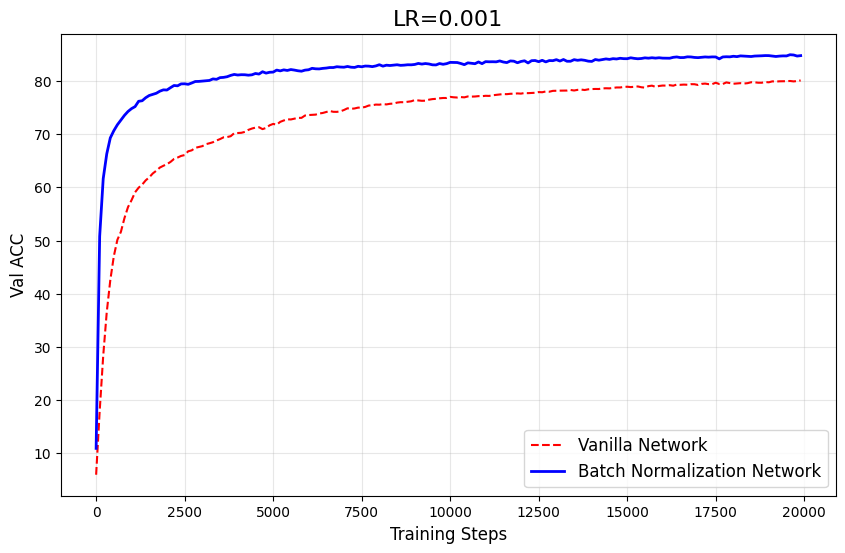

In [ ]:
# small_lr_bn_history
plot_experiments(steps_vanilla=small_lr_vanilla_history["steps"]
                 ,val_loss_or_acc_van=small_lr_vanilla_history["val_acc"],
                 steps_bn=small_lr_bn_history["steps"],
                 val_loss_acc_bn=small_lr_bn_history["val_acc"],
                 title="LR=0.001",
                 ylabel="Val ACC",log=False)

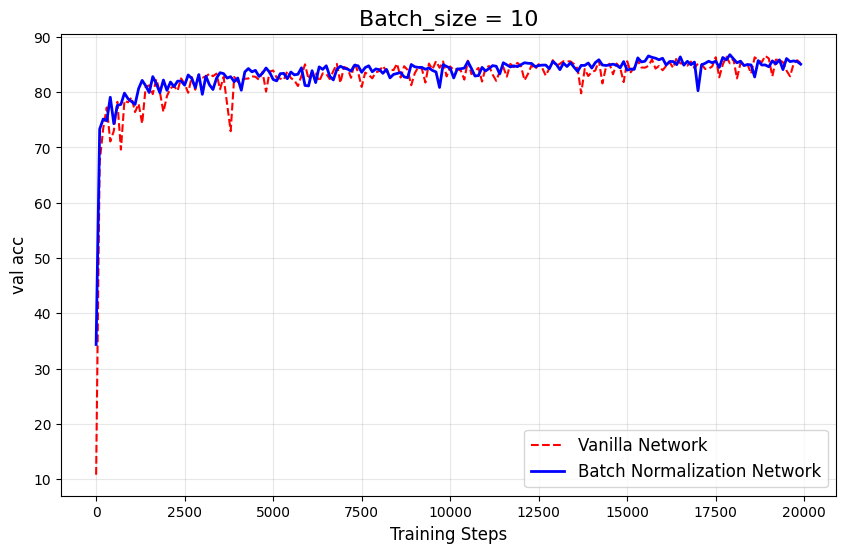

In [ ]:
plot_experiments(steps_vanilla=small_batchsize_vanilla_history["steps"]
                 ,val_loss_or_acc_van=small_batchsize_vanilla_history["val_acc"],
                 steps_bn=small_batchsize_bn_history["steps"],
                 val_loss_acc_bn=small_batchsize_bn_history["val_acc"],
                 title="Batch_size = 10",
                 ylabel="val acc",log=False)

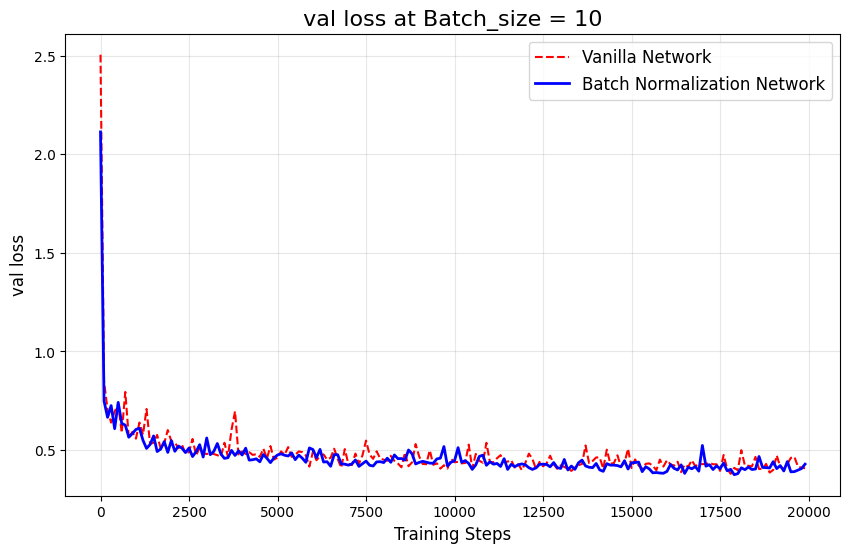

In [ ]:
plot_experiments(steps_vanilla=small_batchsize_vanilla_history["steps"]
                 ,val_loss_or_acc_van=small_batchsize_vanilla_history["val_loss"],
                 steps_bn=small_batchsize_bn_history["steps"],
                 val_loss_acc_bn=small_batchsize_bn_history["val_loss"],
                 title=" val loss at Batch_size = 10 ",
                 ylabel="val loss",log=False)

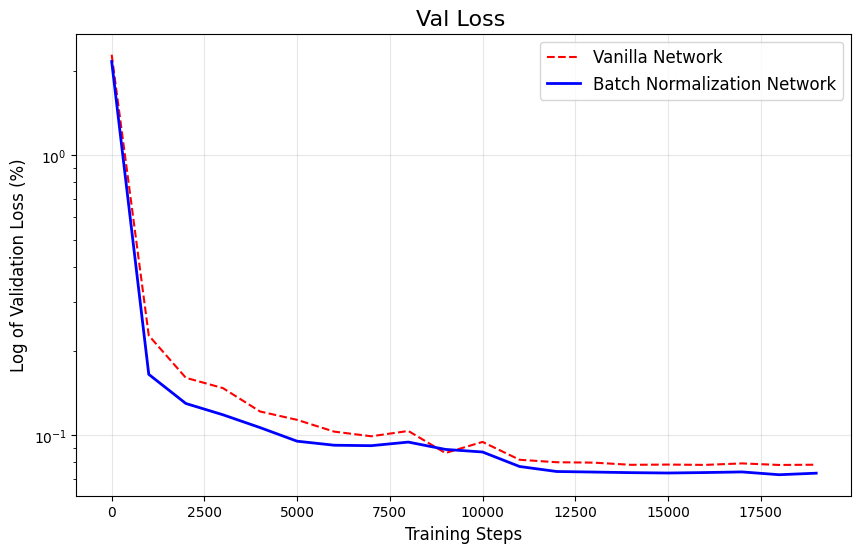

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(steps_vanilla,val_loss_vanilla,label="Vanilla Network",color="red",linestyle="--")
plt.plot(steps_bn,val_loss_bn,label="Batch Normalization Network", color="blue", linewidth=2)
# plt.xlim(0,10000)
# plt.ylim(0.0, 0.5)
plt.yscale('log')
plt.title("Val Loss ", fontsize=16)
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Log of Validation Loss (%)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True,alpha=0.3)

plt.show()

EXPERIMENT TRACKER  VANILLA VS BATCH NORM
                                                ACCURACY
EXPERIEMENT     STEPS       LEARNING RATE   Vanilla     BN

EXTENDED        20,000     0.1 -> 0.01     97.28       97.50
F-EXTENDED      20,000      0.1 -> 0.01    87.71      88.60

BASELINE       5,000      0.1             96.53        97.12
F-BASELINE     5,000      0.1             85.63        86.72

F-STRESS Test  10000      1               65.72        10.01

STRESS TEST    10000    

  


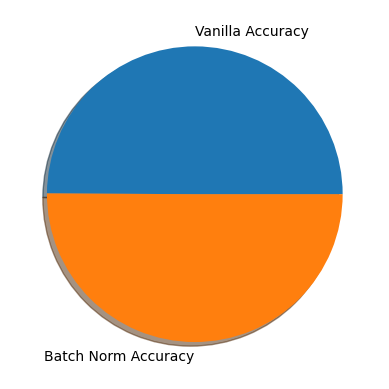